## imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import numpy as np
import os
import re
import pickle
from num2words import num2words
from scipy.spatial.distance import cdist
from scipy.signal import resample
from scipy.stats import zscore
from scipy.spatial.distance import correlation
from scipy.interpolate import interp1d as interpolate
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import seaborn as sns
%matplotlib inline

## set paths

In [2]:
ep_model_dir = '../../data/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings')
pickle_dir = '../../data/pickles/'

## load data

In [3]:
# episode trajectories
episode_trajectories = {episode : np.load(os.path.join(ep_traj_dir,episode+'_model_t100_w50_res.npy')) for episode
                       in ['atlep1','atlep2','arrdev']}

# episode events
episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# individual participant trajectories
participant_trajectories = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_traj_dir):
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories = {rectype : np.load(os.path.join(rec_traj_dir, rectype, 'avg_trajectory.npy')) for 
                               rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}


# individual participant events
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_seg_dir):
    events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    for f_name in events_models:
        m = np.load(os.path.join(root,f_name))
        participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))

# average participant events
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}
        
# episode-recall event mappings
event_mappings = dict()
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    with open(os.path.join(rec_seg_dir,rectype,'event_mappings.p'), 'rb') as f:
        event_mappings[rectype] = pickle.load(f)
        
# session 1/session 2 psiturk ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

## compare variability among participants for immediate and delayed recall

In [5]:
imm_trajs = [traj for turkid, traj in participant_trajectories['atlep1']]
sub_dists_i = []

for traj in imm_trajs:
    sub_dists_i.append(np.diag(cdist(avg_participant_trajectories['atlep1'], traj, metric='euclidean')))

immediate_variance = np.mean(sub_dists_i, axis=0)

In [6]:
del_trajs = [traj for turkid, traj in participant_trajectories['delayed']]
sub_dists_d = []

for traj in del_trajs:
    sub_dists_d.append(np.diag(cdist(avg_participant_trajectories['delayed'], traj, metric='euclidean')))

delayed_variance = np.mean(sub_dists_d, axis=0)

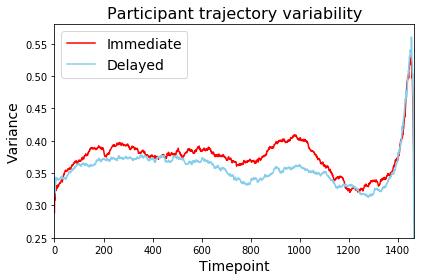

In [7]:
plt.plot(immediate_variance, color='red', label='Immediate')
plt.plot(delayed_variance, color='skyblue', label='Delayed')
plt.xlim((0,1466))
plt.ylim((0.25,0.58))
plt.title('Participant trajectory variability', fontsize=16)
plt.xlabel('Timepoint', fontsize=14)
plt.ylabel('Variance', fontsize=14)
plt.legend(loc=2, fontsize=14)

plt.tight_layout()
#plt.savefig('../../figures/immediate-delayed-variance.pdf')

## compare episode-recall distance for each timepoint between immediate and delayed recall

In [10]:
immediate_distance = np.diag(cdist(avg_participant_trajectories['atlep1'], episode_trajectories['atlep1'], 
                                   metric='euclidean'))
delayed_distance = np.diag(cdist(avg_participant_trajectories['delayed'], episode_trajectories['atlep1'], 
                                   metric='euclidean'))

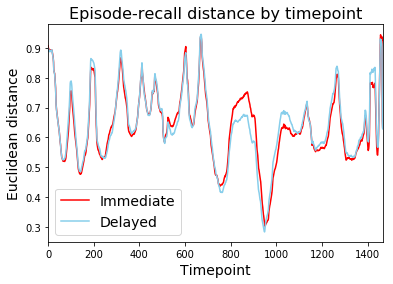

In [11]:
plt.plot(immediate_distance, color='red', label='Immediate')
plt.plot(delayed_distance, color='skyblue', label='Delayed')
plt.xlim((0,1466))
#plt.ylim((0.25,0.58))
plt.title('Episode-recall distance by timepoint', fontsize=16)
plt.xlabel('Timepoint', fontsize=14)
plt.ylabel('Euclidean distance', fontsize=14)
plt.legend(fontsize=14)
#plt.savefig('../../figures/immediate-delayed-ep-rec-euc-dist.pdf')

In [12]:
immediate_distance = np.diag(1-cdist(avg_participant_trajectories['atlep1'], episode_trajectories['atlep1'], 
                                   metric='correlation'))
delayed_distance = np.diag(1-cdist(avg_participant_trajectories['delayed'], episode_trajectories['atlep1'], 
                                   metric='correlation'))

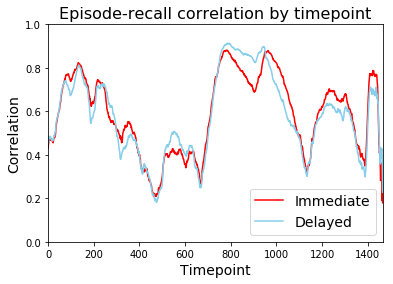

In [13]:
plt.plot(immediate_distance, color='red', label='Immediate')
plt.plot(delayed_distance, color='skyblue', label='Delayed')
plt.xlim((0,1466))
plt.ylim((0,1))
plt.title('Episode-recall correlation by timepoint', fontsize=16)
plt.xlabel('Timepoint', fontsize=14)
plt.ylabel('Correlation', fontsize=14)
plt.legend(fontsize=14)
#plt.savefig('../../figures/immediate-delayed-ep-rec-corr.pdf')

## try with sherlock-proportional episode windows

In [188]:
# ep_prop_traj_dir = os.path.join(ep_model_dir, 't100_wProp', 'trajectories')
# rec_prop_traj_dir = os.path.join(rec_traj_dir, 'vidwProp')

# # episode trajectories
# episode_trajectories_prop = {episode : np.load(os.path.join(ep_prop_traj_dir, episode+'_model_t100_wProp_res.npy')) 
#                         for episode in ['atlep1','atlep2','arrdev']}

# # individual participant trajectories
# participant_trajectories_prop = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

# for root, dirs, files in os.walk(rec_prop_traj_dir):
#     traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
#     for f_name in traj_models:
#         t = np.load(os.path.join(root,f_name))
#         participant_trajectories_prop[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# # average participant trajectories
# avg_participant_trajectories_prop = {rectype : np.load(os.path.join(rec_prop_traj_dir, rectype, 
#                                                                     'avg_trajectory.npy')) 
#                                      for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}

In [189]:
# imm_trajs = [traj for turkid, traj in participant_trajectories_prop['atlep1']]
# sub_dists_i = []

# for traj in imm_trajs:
#     sub_dists_i.append(np.diag(cdist(avg_participant_trajectories_prop['atlep1'], traj, metric='euclidean')))

# immediate_variance = np.mean(sub_dists_i, axis=0)

In [190]:
# del_trajs = [traj for turkid, traj in participant_trajectories_prop['delayed']]
# sub_dists_d = []

# for traj in del_trajs:
#     sub_dists_d.append(np.diag(cdist(avg_participant_trajectories_prop['delayed'], traj, metric='euclidean')))

# delayed_variance = np.mean(sub_dists_d, axis=0)

In [191]:
# plt.plot(immediate_variance, color='red', label='Immediate')
# plt.plot(delayed_variance, color='skyblue', label='Delayed')
# plt.xlim((0,1466))
# plt.ylim((0.25,0.58))
# plt.title('Participant trajectory variability', fontsize=16)
# plt.xlabel('Timepoint', fontsize=14)
# plt.ylabel('Variance', fontsize=14)
# plt.legend(loc=2, fontsize=14)

# plt.tight_layout()
# #plt.savefig('../../figures/immediate-delayed-variance.pdf')

In [192]:
# immediate_distance = np.diag(cdist(avg_participant_trajectories_prop['atlep1'], episode_trajectories_prop['atlep1'], 
#                                    metric='euclidean'))
# delayed_distance = np.diag(cdist(avg_participant_trajectories_prop['delayed'], episode_trajectories_prop['atlep1'], 
#                                    metric='euclidean'))

In [193]:
# plt.plot(immediate_distance, color='red', label='Immediate')
# plt.plot(delayed_distance, color='skyblue', label='Delayed')
# plt.xlim((0,1466))
# #plt.ylim((0.25,0.58))
# plt.title('Episode-recall distance by timepoint', fontsize=16)
# plt.xlabel('Timepoint', fontsize=14)
# plt.ylabel('Euclidean distance', fontsize=14)
# plt.legend(fontsize=14)
# #plt.savefig('../../figures/immediate-delayed-ep-rec-euc-dist.pdf')

In [194]:
# immediate_distance = np.diag(1-cdist(avg_participant_trajectories_prop['atlep1'], episode_trajectories_prop['atlep1'], 
#                                    metric='correlation'))
# delayed_distance = np.diag(1-cdist(avg_participant_trajectories_prop['delayed'], episode_trajectories_prop['atlep1'], 
#                                    metric='correlation'))

In [195]:
# plt.plot(immediate_distance, color='red', label='Immediate')
# plt.plot(delayed_distance, color='skyblue', label='Delayed')
# plt.xlim((0,1466))
# plt.ylim((0,1))
# plt.title('Episode-recall correlation by timepoint', fontsize=16)
# plt.xlabel('Timepoint', fontsize=14)
# plt.ylabel('Correlation', fontsize=14)
# plt.legend(fontsize=14)
# #plt.savefig('../../figures/immediate-delayed-ep-rec-corr.pdf')

In [196]:
# for i, rectype in enumerate(participant_trajectories.keys()):
#     test = [traj for turkid, traj in participant_trajectories[rectype]]
#     plt.subplot(2,3,i+1)
#     plt.plot(np.mean(np.var(test, axis=0), axis=1))
#     plt.title(rectype)
    
# plt.tight_layout()
# plt.savefig('/Users/paxtonfitzpatrick/Desktop/variances')

# compare by events

In [74]:
ep_events = episode_events['atlep1']
imm_events = participant_events['atlep1']
del_events = participant_events['delayed']
imm_matches = event_mappings['atlep1']
del_matches = event_mappings['delayed']

## compare total number of events per participant

In [64]:
n_events = dict.fromkeys(id_maps.keys())

for sid in n_events.keys():
    tid1, n_es1  = next((tid, len(es)) for tid, es in imm_matches if tid == id_maps[sid]['session 1'])
    tid2, n_es2 = next((tid, len(es)) for tid, es in del_matches if tid == id_maps[sid]['session 2'])
    n_events[sid] = (n_es1, n_es2)

In [65]:
print(np.mean([ne[0] for ne in n_events.values()]))
print(np.mean([ne[1] for ne in n_events.values()]))
print(np.mean([ne[0] for ne in n_events.values()]) - np.mean([ne[1] for ne in n_events.values()]))

17.389830508474578
14.203389830508474
3.186440677966104


## compare total number of UNIQUE events per participant

In [66]:
n_unique_events = dict.fromkeys(id_maps.keys())

for sid in n_unique_events.keys():
    tid1, n_ues1  = next((tid, len(np.unique(es))) for tid, es in imm_matches if tid == id_maps[sid]['session 1'])
    tid2, n_ues2 = next((tid, len(np.unique(es))) for tid, es in del_matches if tid == id_maps[sid]['session 2'])
    n_unique_events[sid] = (n_ues1, n_ues2)

In [68]:
print(np.mean([ne[0] for ne in n_unique_events.values()]))
print(np.mean([ne[1] for ne in n_unique_events.values()]))
print(np.mean([ne[0] for ne in n_unique_events.values()]) - np.mean([ne[1] for ne in n_unique_events.values()]))

11.40677966101695
9.64406779661017
1.7627118644067803


## compare distance from each recall event to corresponding episode event

### (closest matched event)

In [354]:
multiindex = pd.MultiIndex.from_product([list(range(len(ep_events)))+['average'], ['imm_dist','del_dist','diff']], 
                                        names=['event', 'distance'])
event_match_distances = pd.DataFrame(columns=[k for k in id_maps.keys()], index=multiindex)

for sid in event_match_distances.columns:
    
    sub_i_ds = []
    sub_d_ds = []
    sub_diffs = []
        
    # get participant's immediate and delayed recall events and matches
    sub_i_evs = next(sub_evs for tid, sub_evs in imm_events if tid == id_maps[sid]['session 1'])
    sub_i_ms = next(sub_ms for tid, sub_ms in imm_matches if tid == id_maps[sid]['session 1'])
    
    sub_d_evs = next(sub_evs for tid, sub_evs in del_events if tid == id_maps[sid]['session 2'])
    sub_d_ms = next(sub_ms for tid, sub_ms in del_matches if tid == id_maps[sid]['session 2'])
    

    # for each episode event
    for i, ep_e in enumerate(ep_events):
        # if the subject recalled that event
        if i in sub_i_ms and i in sub_d_ms:
            # find the distance between the episode event and closest matching recalled event
            mindist_i = np.min(cdist([ep_e], sub_i_evs[np.where(sub_i_ms == i)], metric='euclidean'))
            mindist_d = np.min(cdist([ep_e], sub_d_evs[np.where(sub_d_ms == i)], metric='euclidean'))
            mindist_diff = mindist_d - mindist_i
            
            event_match_distances.at[(i, 'imm_dist'), sid] = mindist_i
            event_match_distances.at[(i, 'del_dist'), sid] = mindist_d
            event_match_distances.at[(i, 'diff'), sid] = mindist_diff
            
            sub_i_ds.append(mindist_i)
            sub_d_ds.append(mindist_d)
            sub_diffs.append(mindist_diff)
            
    event_match_distances.at[('average','imm_dist'), sid] = np.mean(sub_i_ds)
    event_match_distances.at[('average','del_dist'), sid] = np.mean(sub_d_ds)
    event_match_distances.at[('average','diff'), sid] = np.mean(sub_diffs)
            
event_match_distances.dropna(how='all', inplace=True)
event_match_distances['average'] = event_match_distances.mean(axis=1)

In [356]:
event_match_distances

MD-101218-A-01 MD-101218-B-01 MD-101218-A-02 MD-101218-B-02  \
event   distance                                                               
0       imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
1       imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
2       imm_dist       0.416488            NaN            NaN            NaN   
        del_dist       0.277924            NaN            NaN            NaN   
        diff          -0.138564            NaN            NaN            NaN   
3       imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
4       imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
5       imm_dist            NaN            NaN            NaN       0.457183   
        del_dist            NaN            NaN            NaN       0.566441   
        diff                NaN            NaN            NaN       0.109257   
6       imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
7       imm_dist       0.598056            NaN       0.658829            NaN   
        del_dist       0.541091            NaN       0.481076            NaN   
        diff         -0.0569656            NaN      -0.177753            NaN   
8       imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
9       imm_dist        0.57006            NaN            NaN            NaN   
        del_dist       0.620193            NaN            NaN            NaN   
        diff          0.0501332            NaN            NaN            NaN   
...                         ...            ...            ...            ...   
23      imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
24      imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
25      imm_dist            NaN       0.514012            NaN            NaN   
        del_dist            NaN       0.530657            NaN            NaN   
        diff                NaN      0.0166455            NaN            NaN   
26      imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
27      imm_dist       0.455984            NaN            NaN            NaN   
        del_dist       0.651624            NaN            NaN            NaN   
        diff            0.19564            NaN            NaN            NaN   
28      imm_dist            NaN            NaN            NaN       0.541594   
        del_dist            NaN            NaN            NaN       0.321824   
        diff     

### (average of matched events)

In [357]:
multiindex = pd.MultiIndex.from_product([list(range(len(ep_events)))+['average'], ['imm_dist','del_dist','diff']], 
                                        names=['event', 'distance'])
event_match_distances = pd.DataFrame(columns=[k for k in id_maps.keys()], index=multiindex)

for sid in event_match_distances.columns:
    
    sub_i_ds = []
    sub_d_ds = []
    sub_diffs = []
        
    # get participant's immediate and delayed recall events and matches
    sub_i_evs = next(sub_evs for tid, sub_evs in imm_events if tid == id_maps[sid]['session 1'])
    sub_i_ms = next(sub_ms for tid, sub_ms in imm_matches if tid == id_maps[sid]['session 1'])
    
    sub_d_evs = next(sub_evs for tid, sub_evs in del_events if tid == id_maps[sid]['session 2'])
    sub_d_ms = next(sub_ms for tid, sub_ms in del_matches if tid == id_maps[sid]['session 2'])
    

    # for each episode event
    for i, ep_e in enumerate(ep_events):
        # if the subject recalled that event
        if i in sub_i_ms and i in sub_d_ms:
            # find the distance between the episode event and closest matching recalled event
            avgdist_i = np.mean(cdist([ep_e], sub_i_evs[np.where(sub_i_ms == i)], metric='euclidean'))
            avgdist_d = np.mean(cdist([ep_e], sub_d_evs[np.where(sub_d_ms == i)], metric='euclidean'))
            avgdist_diff = avgdist_d - avgdist_i
            
            event_match_distances.at[(i, 'imm_dist'), sid] = avgdist_i
            event_match_distances.at[(i, 'del_dist'), sid] = avgdist_d
            event_match_distances.at[(i, 'diff'), sid] = avgdist_diff
            
            sub_i_ds.append(avgdist_i)
            sub_d_ds.append(avgdist_d)
            sub_diffs.append(avgdist_diff)
            
    event_match_distances.at[('average','imm_dist'), sid] = np.mean(sub_i_ds)
    event_match_distances.at[('average','del_dist'), sid] = np.mean(sub_d_ds)
    event_match_distances.at[('average','diff'), sid] = np.mean(sub_diffs)
            
event_match_distances.dropna(how='all', inplace=True)
event_match_distances['average'] = event_match_distances.mean(axis=1)

In [358]:
event_match_distances

MD-101218-A-01 MD-101218-B-01 MD-101218-A-02 MD-101218-B-02  \
event   distance                                                               
0       imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
1       imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
2       imm_dist       0.497096            NaN            NaN            NaN   
        del_dist       0.277924            NaN            NaN            NaN   
        diff          -0.219172            NaN            NaN            NaN   
3       imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
4       imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
5       imm_dist            NaN            NaN            NaN       0.457183   
        del_dist            NaN            NaN            NaN       0.566441   
        diff                NaN            NaN            NaN       0.109257   
6       imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
7       imm_dist       0.598056            NaN       0.658829            NaN   
        del_dist       0.541091            NaN       0.481076            NaN   
        diff         -0.0569656            NaN      -0.177753            NaN   
8       imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
9       imm_dist        0.57006            NaN            NaN            NaN   
        del_dist       0.620193            NaN            NaN            NaN   
        diff          0.0501332            NaN            NaN            NaN   
...                         ...            ...            ...            ...   
23      imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
24      imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
25      imm_dist            NaN       0.516208            NaN            NaN   
        del_dist            NaN       0.530657            NaN            NaN   
        diff                NaN      0.0144495            NaN            NaN   
26      imm_dist            NaN            NaN            NaN            NaN   
        del_dist            NaN            NaN            NaN            NaN   
        diff                NaN            NaN            NaN            NaN   
27      imm_dist       0.613489            NaN            NaN            NaN   
        del_dist       0.651624            NaN            NaN            NaN   
        diff          0.0381352            NaN            NaN            NaN   
28      imm_dist            NaN            NaN            NaN       0.541594   
        del_dist            NaN            NaN            NaN       0.321824   
        diff     

## compare topic vector correlation between each recall event and corresponding episode event

### (matched event with highest correlation)

In [367]:
multiindex = pd.MultiIndex.from_product([list(range(len(ep_events)))+['average'], ['imm_corr','del_corr','diff']], 
                                        names=['event', 'correlation'])
event_match_corrs = pd.DataFrame(columns=[k for k in id_maps.keys()], index=multiindex)

for sid in event_match_corrs.columns:
    
    sub_i_cs = []
    sub_d_cs = []
    sub_diffs = []
        
    # get participant's immediate and delayed recall events and matches
    sub_i_evs = next(sub_evs for tid, sub_evs in imm_events if tid == id_maps[sid]['session 1'])
    sub_i_ms = next(sub_ms for tid, sub_ms in imm_matches if tid == id_maps[sid]['session 1'])
    
    sub_d_evs = next(sub_evs for tid, sub_evs in del_events if tid == id_maps[sid]['session 2'])
    sub_d_ms = next(sub_ms for tid, sub_ms in del_matches if tid == id_maps[sid]['session 2'])
    

    # for each episode event
    for i, ep_e in enumerate(ep_events):
        # if the subject recalled that event
        if i in sub_i_ms and i in sub_d_ms:
            # compute the correlation between the episode event and most highly correlated matching recalled event
            maxcorr_i = np.max(1-cdist([ep_e], sub_i_evs[np.where(sub_i_ms == i)], metric='correlation'))
            maxcorr_d = np.max(1-cdist([ep_e], sub_d_evs[np.where(sub_d_ms == i)], metric='correlation'))
            maxcorr_diff = maxcorr_d - maxcorr_i
            
            event_match_corrs.at[(i, 'imm_corr'), sid] = maxcorr_i
            event_match_corrs.at[(i, 'del_corr'), sid] = maxcorr_d
            event_match_corrs.at[(i, 'diff'), sid] = maxcorr_diff
            
            sub_i_cs.append(maxcorr_i)
            sub_d_cs.append(maxcorr_d)
            sub_diffs.append(maxcorr_diff)
            
    event_match_corrs.at[('average','imm_corr'), sid] = np.mean(sub_i_cs)
    event_match_corrs.at[('average','del_corr'), sid] = np.mean(sub_d_cs)
    event_match_corrs.at[('average','diff'), sid] = np.mean(sub_diffs)
            
event_match_corrs.dropna(how='all', inplace=True)
event_match_corrs['average'] = event_match_corrs.mean(axis=1)

In [368]:
event_match_corrs

MD-101218-A-01 MD-101218-B-01 MD-101218-A-02  \
event   correlation                                                
0       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
1       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
2       imm_corr          0.915169            NaN            NaN   
        del_corr            0.9686            NaN            NaN   
        diff             0.0534306            NaN            NaN   
3       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
4       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
5       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
6       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
7       imm_corr          0.769222            NaN       0.741226   
        del_corr          0.834728            NaN       0.913549   
        diff             0.0655063            NaN       0.172322   
8       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
9       imm_corr          0.713918            NaN            NaN   
        del_corr          0.630477            NaN            NaN   
        diff            -0.0834411            NaN            NaN   
...                            ...            ...            ...   
23      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
24      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
25      imm_corr               NaN       0.668825            NaN   
        del_corr               NaN       0.656481            NaN   
        diff                   NaN     -0.0123444            NaN   
26      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
27      imm_corr           0.90028            NaN            NaN   
        del_corr          0.707765            NaN            NaN   
        diff             -0.192515            NaN            NaN   
28      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
29      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
30      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
31      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        

### (average of matched events

In [369]:
multiindex = pd.MultiIndex.from_product([list(range(len(ep_events)))+['average'], ['imm_corr','del_corr','diff']], 
                                        names=['event', 'correlation'])
event_match_corrs = pd.DataFrame(columns=[k for k in id_maps.keys()], index=multiindex)

for sid in event_match_corrs.columns:
    
    sub_i_cs = []
    sub_d_cs = []
    sub_diffs = []
        
    # get participant's immediate and delayed recall events and matches
    sub_i_evs = next(sub_evs for tid, sub_evs in imm_events if tid == id_maps[sid]['session 1'])
    sub_i_ms = next(sub_ms for tid, sub_ms in imm_matches if tid == id_maps[sid]['session 1'])
    
    sub_d_evs = next(sub_evs for tid, sub_evs in del_events if tid == id_maps[sid]['session 2'])
    sub_d_ms = next(sub_ms for tid, sub_ms in del_matches if tid == id_maps[sid]['session 2'])
    

    # for each episode event
    for i, ep_e in enumerate(ep_events):
        # if the subject recalled that event
        if i in sub_i_ms and i in sub_d_ms:
            # compute the correlation between the episode event and most highly correlated matching recalled event
            meancorr_i = np.mean(1-cdist([ep_e], sub_i_evs[np.where(sub_i_ms == i)], metric='correlation'))
            meancorr_d = np.mean(1-cdist([ep_e], sub_d_evs[np.where(sub_d_ms == i)], metric='correlation'))
            meancorr_diff = meancorr_d - meancorr_i
            
            event_match_corrs.at[(i, 'imm_corr'), sid] = meancorr_i
            event_match_corrs.at[(i, 'del_corr'), sid] = meancorr_d
            event_match_corrs.at[(i, 'diff'), sid] = meancorr_diff
            
            sub_i_cs.append(meancorr_i)
            sub_d_cs.append(meancorr_d)
            sub_diffs.append(meancorr_diff)
            
    event_match_corrs.at[('average','imm_corr'), sid] = np.mean(sub_i_cs)
    event_match_corrs.at[('average','del_corr'), sid] = np.mean(sub_d_cs)
    event_match_corrs.at[('average','diff'), sid] = np.mean(sub_diffs)
            
event_match_corrs.dropna(how='all', inplace=True)
event_match_corrs['average'] = event_match_corrs.mean(axis=1)

In [370]:
event_match_corrs

MD-101218-A-01 MD-101218-B-01 MD-101218-A-02  \
event   correlation                                                
0       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
1       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
2       imm_corr          0.856091            NaN            NaN   
        del_corr            0.9686            NaN            NaN   
        diff              0.112509            NaN            NaN   
3       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
4       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
5       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
6       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
7       imm_corr          0.769222            NaN       0.741226   
        del_corr          0.834728            NaN       0.913549   
        diff             0.0655063            NaN       0.172322   
8       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
9       imm_corr          0.713918            NaN            NaN   
        del_corr          0.630477            NaN            NaN   
        diff            -0.0834411            NaN            NaN   
...                            ...            ...            ...   
23      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
24      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
25      imm_corr               NaN       0.664982            NaN   
        del_corr               NaN       0.656481            NaN   
        diff                   NaN    -0.00850104            NaN   
26      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
27      imm_corr          0.745934            NaN            NaN   
        del_corr          0.707765            NaN            NaN   
        diff            -0.0381693            NaN            NaN   
28      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
29      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
30      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
31      imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        